In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.applications import VGG16
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)



# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 976s 6us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [9]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif"]
plt.rcParams["font.size"] = 15


(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize ONCE
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0



print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


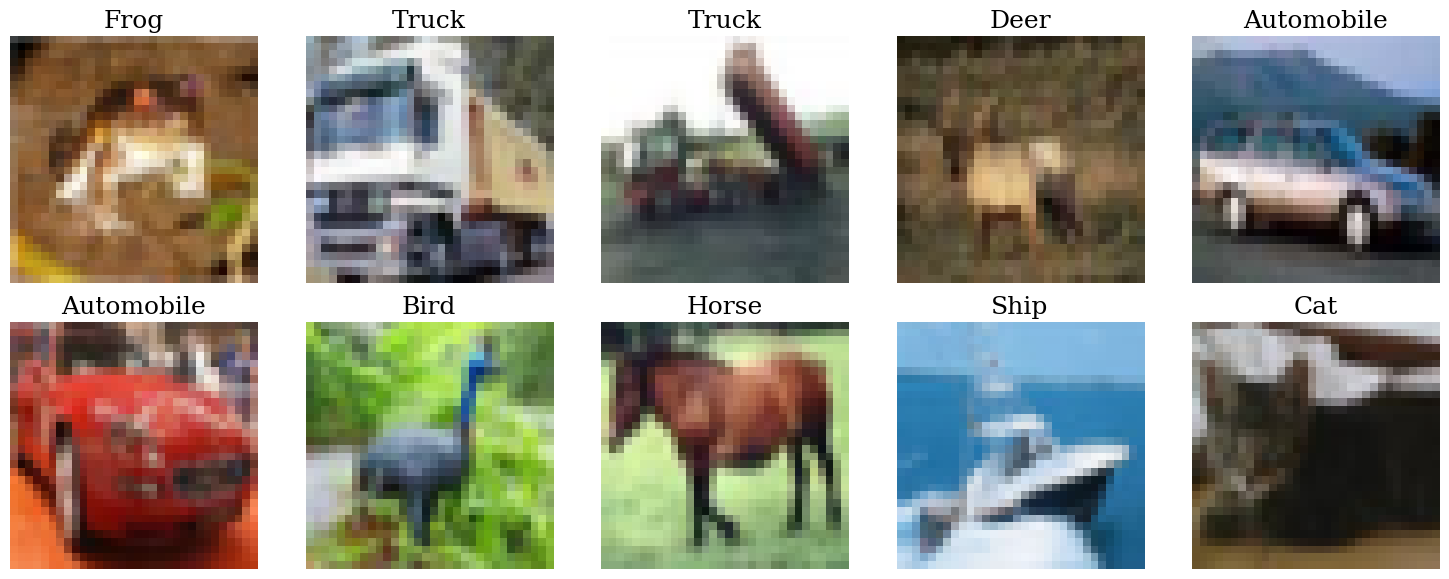

In [7]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "sample_cifar10.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [10]:
input_shape=(32, 32, 3)
y_train_cat = tf.keras.utils.to_categorical(
    y_train,
    num_classes=10
)

y_test_cat = tf.keras.utils.to_categorical(
    y_test,
    num_classes=10
)

print("Training labels:", y_train_cat.shape)
print("Testing labels:", y_test_cat.shape)

Training labels: (50000, 10)
Testing labels: (10000, 10)


In [11]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3)
)

print("VGG16 loaded successfully.")
print("Total layers:", len(base_model.layers))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
VGG16 loaded successfully.
Total layers: 19


In [12]:
base_model.trainable = False

print(
    "Trainable layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Trainable layers: 0


In [15]:
base_model.trainable = False

print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))
print("Total layers:", len(base_model.layers))

Trainable layers: 0
Total layers: 19


In [13]:
model = tf.keras.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
start_time = time.time()

history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    batch_size=32,
    epochs=10,
    verbose=1
)

training_time = time.time() - start_time

print("\nTraining Time:")
print(f"{training_time:.2f} seconds")
print(f"{training_time / 60:.2f} minutes")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6177 - loss: 1.0886 - val_accuracy: 0.6035 - val_loss: 1.1294
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6347 - loss: 1.0417 - val_accuracy: 0.6040 - val_loss: 1.1229
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6496 - loss: 0.9994 - val_accuracy: 0.6156 - val_loss: 1.0984
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6633 - loss: 0.9616 - val_accuracy: 0.6106 - val_loss: 1.1211
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6742 - loss: 0.9278 - val_accuracy: 0.6121 - val_loss: 1.1373
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6845 - loss: 0.8972 - val_accuracy: 0.6184 - val_loss: 1.1036
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6964 - loss: 0.8664 - val_accuracy: 0.6179 - val_loss: 1.1211
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7061 - lo

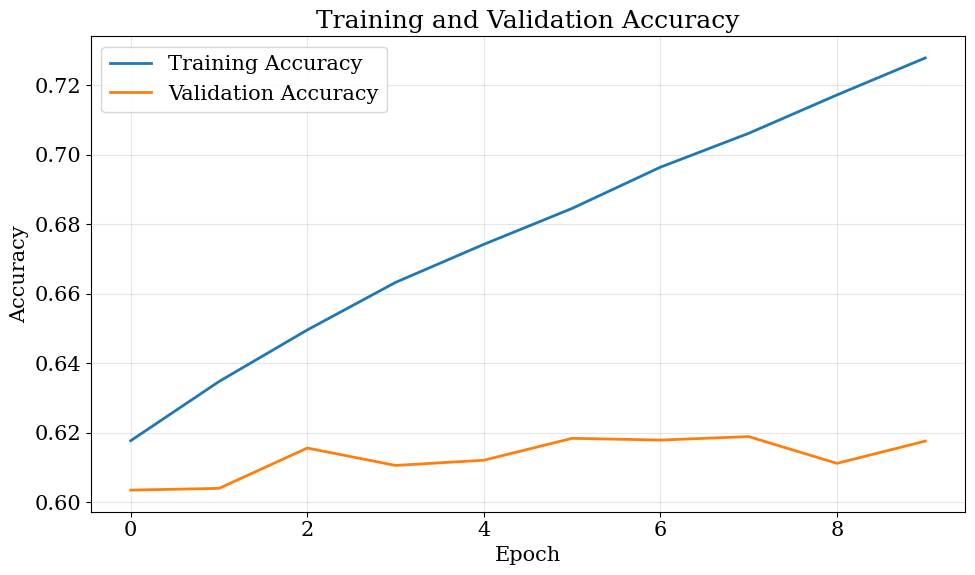

In [17]:
    plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "training_validation_accuracy.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()

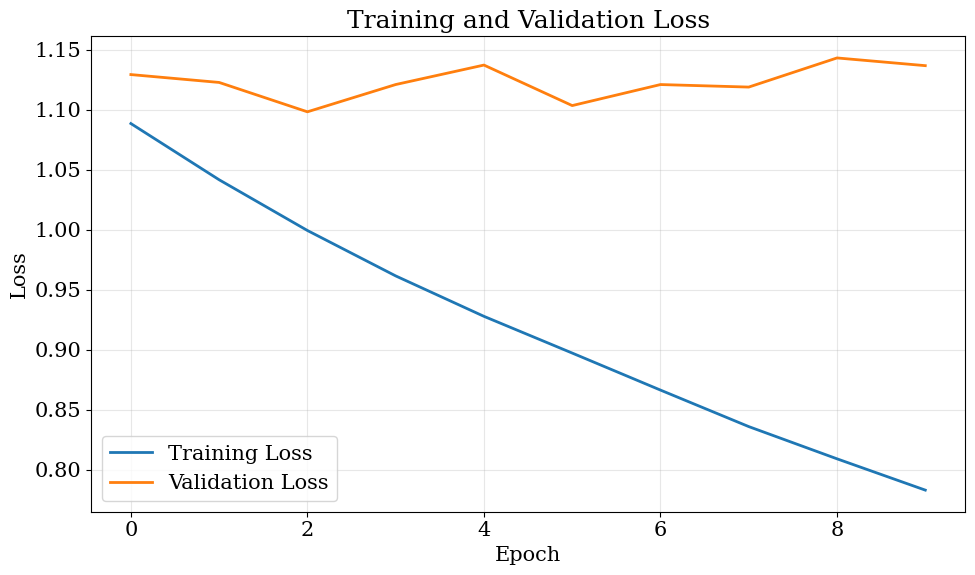

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "training_validation_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [19]:
# Keep all layers frozen initially
base_model.trainable = True

# Freeze all layers except the last convolutional block
for layer in base_model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True
    else:
        layer.trainable = False

# Check trainable layers
for layer in base_model.layers:
    print(
        layer.name,
        "Trainable:" if layer.trainable else "Frozen"
    )

input_layer Frozen
block1_conv1 Frozen
block1_conv2 Frozen
block1_pool Frozen
block2_conv1 Frozen
block2_conv2 Frozen
block2_pool Frozen
block3_conv1 Frozen
block3_conv2 Frozen
block3_conv3 Frozen
block3_pool Frozen
block4_conv1 Frozen
block4_conv2 Frozen
block4_conv3 Frozen
block4_pool Frozen
block5_conv1 Trainable:
block5_conv2 Trainable:
block5_conv3 Trainable:
block5_pool Trainable:


In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
start_finetuning_time = time.time()

fine_tune_history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    batch_size=32,
    epochs=5,
    verbose=1
)

fine_tuning_time = time.time() - start_finetuning_time

print("\nFine-tuning Time:")
print(f"{fine_tuning_time:.2f} seconds")
print(f"{fine_tuning_time / 60:.2f} minutes")

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.6448 - loss: 1.0194 - val_accuracy: 0.6696 - val_loss: 0.9390
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7301 - loss: 0.7669 - val_accuracy: 0.7122 - val_loss: 0.8256
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7720 - loss: 0.6394 - val_accuracy: 0.7176 - val_loss: 0.8183
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8107 - loss: 0.5263 - val_accuracy: 0.7310 - val_loss: 0.8509
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8487 - loss: 0.4174 - val_accuracy: 0.7274 - val_loss: 0.8645

Fine-tuning Time:
109.96 seconds
1.83 minutes


In [22]:
# Generate predictions
y_pred_prob = model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


In [23]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Testing Accuracy : {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-score         : {f1:.4f}")

Testing Accuracy : 0.7274
Precision        : 0.7403
Recall           : 0.7274
F1-score         : 0.7264


In [24]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.78      0.78      0.78      1000
  Automobile       0.79      0.86      0.82      1000
        Bird       0.70      0.65      0.67      1000
         Cat       0.48      0.69      0.56      1000
        Deer       0.76      0.58      0.66      1000
         Dog       0.77      0.47      0.58      1000
        Frog       0.72      0.81      0.76      1000
       Horse       0.80      0.79      0.80      1000
        Ship       0.83      0.84      0.84      1000
       Truck       0.77      0.81      0.79      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000



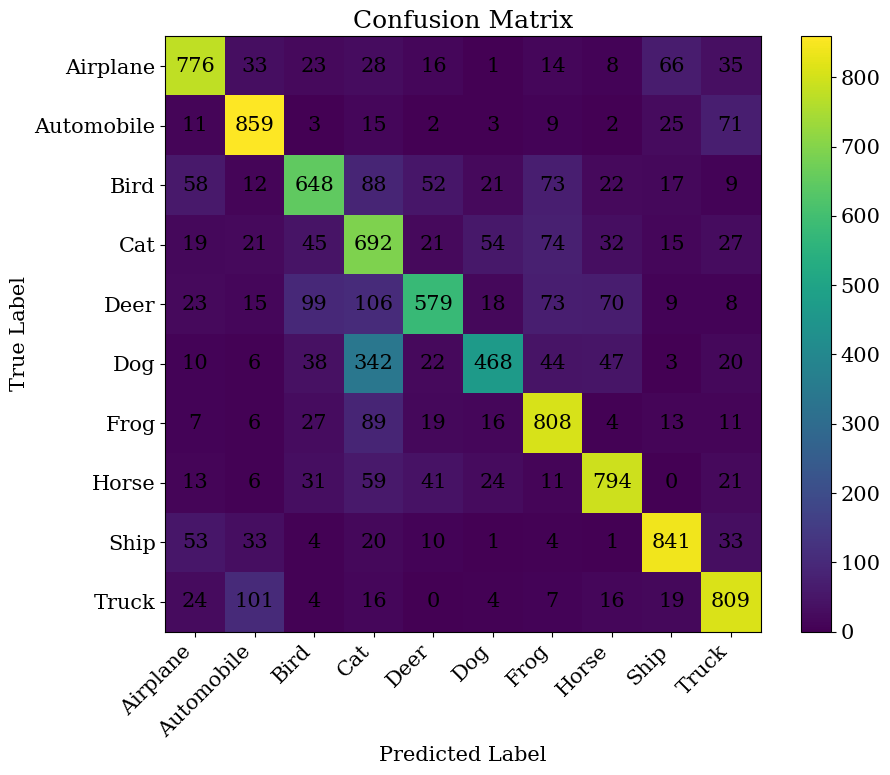

In [25]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    class_names
)

# Add values inside cells
for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

plt.savefig(
    "confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [26]:
training_accuracy = history.history["accuracy"][-1]
testing_accuracy = accuracy

total_params = model.count_params()


print(f"Training Accuracy : {training_accuracy:.4f}")
print(f"Testing Accuracy  : {testing_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-score          : {f1:.4f}")
print(f"Training Time     : {training_time:.2f} seconds")
print(f"Total Parameters  : {total_params:,}")

Training Accuracy : 0.7278
Testing Accuracy  : 0.7274
Precision         : 0.7403
Recall            : 0.7274
F1-score          : 0.7264
Training Time     : 162.78 seconds
Total Parameters  : 14,848,586
